<a href="https://colab.research.google.com/github/hawa1983/MG-628/blob/main/Midterm_Regression_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Overview**

This midterm project assesses your ability to apply regression analysis to real-world scenarios relevant to your major using Python. Regression analysis is one of the most widely used statistical tools across disciplines, and Python has become the standard programming language for data analysis in both industry and academia.

You will complete four structured questions, each requiring you to write Python code to analyze a scenario, perform regression analysis, produce visual and statistical outputs, and answer critical thinking questions that demonstrate your understanding beyond mere calculation. Each question contains the following sections:

- **What to Do:** Step-by-step instructions for the analysis you must perform.
- Python Code Template: Starter code you must use, modify, and extend to complete the analysis.
- **Create:** Specific outputs you must produce (tables, charts, regression equations, etc.).
- **Deliverables:** The exact items you must submit for grading.
- **Critical Thinking Questions:** Four questions per scenario requiring interpretation, evaluation, and application.

**Required Python Libraries**

Install the following libraries before beginning. All code templates assume these packages are available.

> *pip install pandas numpy matplotlib seaborn statsmodels scikit-learn scipy*

Standard import block to use at the top of every notebook or script:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## Overview of Data Sets**

**Major**

Business Administration

**Project Title:**
Reviving Growth at NovaTech Solutions

**Data File**

* **Sales Performance** — 1,200 deals with declining deal sizes and lengthening sales cycles

* **Marketing Campaigns** — 48 campaigns across 6 channels with rising cost per lead

* **Customer Accounts** — 420 accounts with satisfaction scores, support tickets, and churn status

* **Financial Summary** — 24 months of revenue, COGS, operating expenses, and net margin

**Major**

Healthcare Administration

**Project Title:**
Reducing Readmissions at Mercy Regional Medical Center

**Data File**

* **Patient Records** — 12,400 discharges with demographics, clinical data, follow-up completion, medication reconciliation, and 30-day readmission outcomes

* **Staffing Data** — 18 months of nurse-to-patient ratios across 4 departments

**Major**

Public Administration

**Project Title:**
Closing the Equity Gap at Riverside County

**Data File**

* **Applications** — 34,000 SNAP/TANF/Medicaid applications with processing times varying by district (11–34 days)

* **District Demographics** —  8 districts with income, poverty rate, minority %, and digital access

* **District Operations** — Caseworker ratios, caseloads, and office hours

* **Client Survey** — 2,800 responses with satisfaction, ease of access, and language barriers

# Case Study 1: Business Administration
*“Reviving Growth at NovaTech Solutions: A Data-Driven Turnaround”*

**Background**

NovaTech Solutions is a mid-sized B2B software company headquartered in Charlotte, North Carolina, with 320 employees and annual revenue of $48 million. After five consecutive years of double-digit growth, the company experienced a sharp slowdown in 2025, with revenue growth falling to just 2.1% and customer churn rising from 8% to 14%. The CEO, Maria Chen, has asked the newly hired Director of Business Analytics, James Okafor, to conduct a comprehensive data analysis to identify the root causes and recommend strategic interventions.

James has access to 24 months of historical data across sales, marketing, customer success, and finance. He needs to present actionable findings to the executive leadership team within three weeks.

**Preliminary Findings**

James’s initial exploratory analysis reveals several patterns. Average deal size has declined from $38,000 to $29,000 over the past year. Sales cycle length has increased from 45 days to 62 days. Marketing spend shifted heavily toward digital channels, but cost per lead increased by 35%. Customer satisfaction scores show a moderate negative correlation (r = –0.68) with the number of support tickets filed. A multiple regression model predicting monthly revenue using marketing spend, average deal size, and sales rep headcount yields R² = 0.76.

The regression output shows: Marketing Spend (b = 1.82, p = 0.003), Average Deal Size (b = 0.94, p = 0.0001), Sales Rep Headcount (b = 12,400, p = 0.085). Additionally, an independent samples t-test comparing churn rates between customers with satisfaction scores above 7 versus those at or below 7 shows a significant difference (t = 3.92, p = 0.0002).

**Question 1: Descriptive and Exploratory Analysis**

## Question 1A: Deal Size and Sales Cycle Trends

*Prompt: Examine the trends in deal size and sales cycle length. What story do these descriptive statistics tell about NovaTech’s sales pipeline health?*

**WHAT TO DO**

1. Load the sales performance dataset and group the data by month.
2. Calculate monthly descriptive statistics for Deal_Size_USD: mean, median, standard deviation.
3. Calculate monthly descriptive statistics for Sales_Cycle_Days: mean, median, standard deviation.
4. Create line charts showing the month-over-month trend for both variables.

**ANSWER THIS:**

1. Analyze how deal sizes and sales cycle lengths have changed over the 24-month period
2. Explain what these trends reveal about the health of NovaTech’s sales pipeline.

**DELIVERABLES**

1. Code cells — All Python code used to load, transform, and analyze the data
2. Two visualizations — Saved as deal_size_trend.png and sales_cycle_trend.png
3. Printed summary tables — Monthly statistics and year-over-year comparison displayed in notebook output
4. Markdown narrative cell — A written interpretation (3–5 sentences) explaining the business implications
5. Responses to the following questions:
    - Analyze how deal sizes and sales cycle lengths have changed over the 24-month period
    - Explain what these trends reveal about the health of NovaTech’s sales pipeline.

### **1a — Trends in Deal Size and Sales Cycle Length**
Goal: Summarize deal size and cycle length over time to assess pipeline health.

***1. Load the sales performance dataset and group the data by month***

In [ ]:

sales_df = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/business_sales_performance.csv')

# Preview dataset
sales_df.head()

,Deal_ID,Month,Region,Sales_Rep_ID,Deal_Size_USD,Sales_Cycle_Days,Monthly_Revenue_USD,Deal_Status
0,D-0001,1,West,REP-029,33854.8100,46,34297.8800,Won
1,D-0002,2,Central,REP-012,38628.5000,55,35775.2800,Won
2,D-0003,3,Central,REP-007,41541.0200,40,43413.5900,Won
3,D-0004,4,West,REP-029,26212.4300,55,28067.3000,Pending
4,D-0005,5,East,REP-011,30907.6200,61,28738.4200,Lost


***2. Calculate monthly descriptive statistics for Deal_Size_USD: mean, median, standard deviation.***

***3. Calculate monthly descriptive statistics for Sales_Cycle_Days: mean, median, standard deviation.***

In [ ]:
monthly_stats = sales_df.groupby('Month').agg({
    'Deal_Size_USD': ['mean','median','std'],
    'Sales_Cycle_Days': ['mean','median','std']
}).reset_index()

monthly_stats

Month Deal_Size_USD                      Sales_Cycle_Days               
                  mean     median       std             mean  median    std
0      1    38026.7636 37544.2850 4605.3351          45.3400 45.0000 8.7216
1      2    37687.6206 38234.5300 4887.8205          44.3600 43.0000 7.7189
2      3    37124.3256 37764.0750 4254.2765          43.6600 44.0000 7.6468
3      4    37218.4746 37894.9200 5348.4726          47.8600 48.0000 7.8766
4      5    35861.1158 35835.9100 4658.3214          48.0600 48.0000 7.0723
5      6    36298.0538 36139.6100 4450.5321          47.4600 45.5000 8.3769
6      7    37003.7090 37802.0500 4723.2418          50.5200 49.0000 8.1947
7      8    34821.4040 34854.8700 3972.2695          50.6400 51.5000 9.6357
8      9    35991.7680 36521.4050 4006.2734          49.8400 50.0000 7.5818
9     10    34825.9896 35236.8000 4672.3142          50.3600 49.5000 6.0903
10    11    34628.3982 34045.9900 5258.8967          50.4400 51.0000 8.4181
11    12    34683.0312 34639.5750 5404.9334          52.4400 54.0000 7.9106
12    13    32800.6996 32530.5600 5217.3120          52.7400 52.0000 8.4511
13    14    32924.4004 33104.8200 5182.0824          53.9400 53.5000 8.8627
14    15    32876.3770 33493.8350 5051.9557          57.8600 56.5000 6.5278
15    16    32015.4978 31641.1000 5558.3375          54.4600 54.5000 9.0896
16    17    31549.9096 32132.6050 4481.4907          55.8800 57.0000 8.0067
17    18    32508.4056 32456.8550 5134.3107          58.0800 57.5000 8.6398
18    19    31210.4926 31057.2000 4875.8561          59.4800 60.0000 7.7729
19    20    28612.1666 27653.5900 4870.9480          60.9800 62.0000 7.8259
20    21    31856.3216 31735.5900 5145.1806          58.9000 60.0000 8.3818
21    22    30483.8518 30900.9450 5226.7757          59.6000 60.0000 7.8011
22    23    28758.5224 27901.9050 5237.2983          61.3800 61.0000 7.0244
23    24    29788.6270 29901.0600 4840.5169          61.8000 62.0000 7.8584

Optionally Flatten Column Names (easier to use)

In [ ]:
monthly_stats.columns = [
    'Month',
    'Deal_Size_Mean',
    'Deal_Size_Median',
    'Deal_Size_STD',
    'Sales_Cycle_Mean',
    'Sales_Cycle_Median',
    'Sales_Cycle_STD'
]

monthly_stats

,Month,Deal_Size_Mean,Deal_Size_Median,Deal_Size_STD,Sales_Cycle_Mean,Sales_Cycle_Median,Sales_Cycle_STD
0,1,38026.7636,37544.2850,4605.3351,45.3400,45.0000,8.7216
1,2,37687.6206,38234.5300,4887.8205,44.3600,43.0000,7.7189
2,3,37124.3256,37764.0750,4254.2765,43.6600,44.0000,7.6468
3,4,37218.4746,37894.9200,5348.4726,47.8600,48.0000,7.8766
4,5,35861.1158,35835.9100,4658.3214,48.0600,48.0000,7.0723
5,6,36298.0538,36139.6100,4450.5321,47.4600,45.5000,8.3769
6,7,37003.7090,37802.0500,4723.2418,50.5200,49.0000,8.1947
7,8,34821.4040,34854.8700,3972.2695,50.6400,51.5000,9.6357
8,9,35991.7680,36521.4050,4006.2734,49.8400,50.0000,7.5818
9,10,34825.9896,35236.8000,4672.3142,50.3600,49.5000,6.0903


***4. Create line charts showing the month-over-month trend for both variables***

Plot Trend for Deal Size

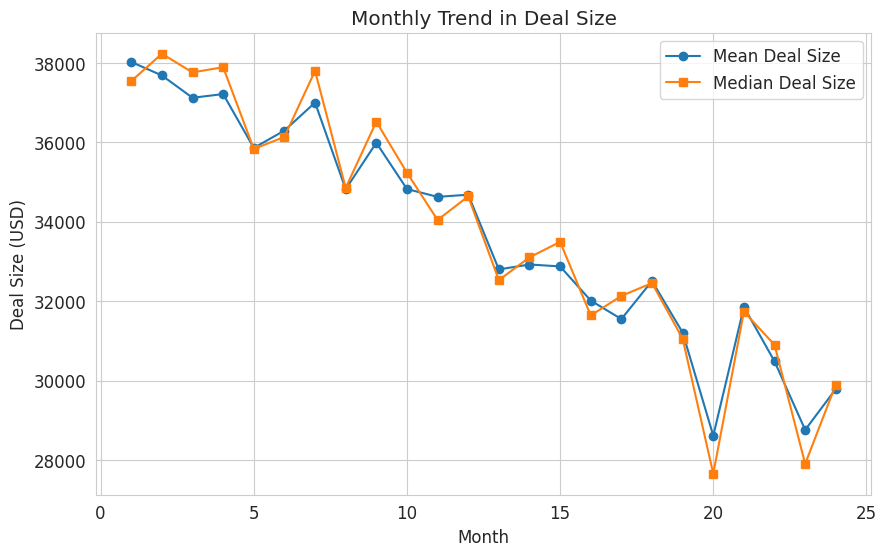

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(monthly_stats['Month'], monthly_stats['Deal_Size_Mean'], marker='o', label='Mean Deal Size')
plt.plot(monthly_stats['Month'], monthly_stats['Deal_Size_Median'], marker='s', label='Median Deal Size')

plt.title('Monthly Trend in Deal Size')
plt.xlabel('Month')
plt.ylabel('Deal Size (USD)')
plt.legend()
plt.grid(True)

plt.show()

Plot Trend for Sales Cycle

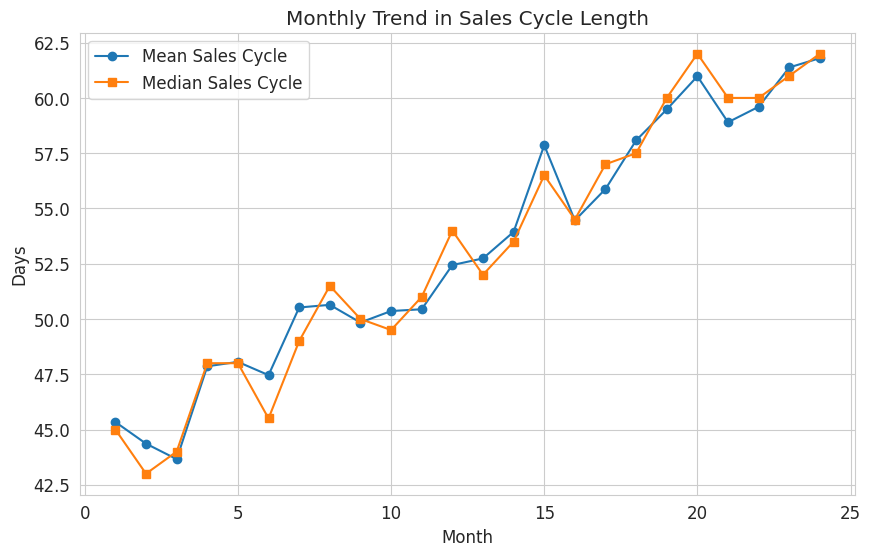

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(monthly_stats['Month'], monthly_stats['Sales_Cycle_Mean'], marker='o', label='Mean Sales Cycle')
plt.plot(monthly_stats['Month'], monthly_stats['Sales_Cycle_Median'], marker='s', label='Median Sales Cycle')

plt.title('Monthly Trend in Sales Cycle Length')
plt.xlabel('Month')
plt.ylabel('Days')
plt.legend()
plt.grid(True)

plt.show()

Optionally Combined Trend Chart (Often Required)

<Figure size 1000x600 with 0 Axes>

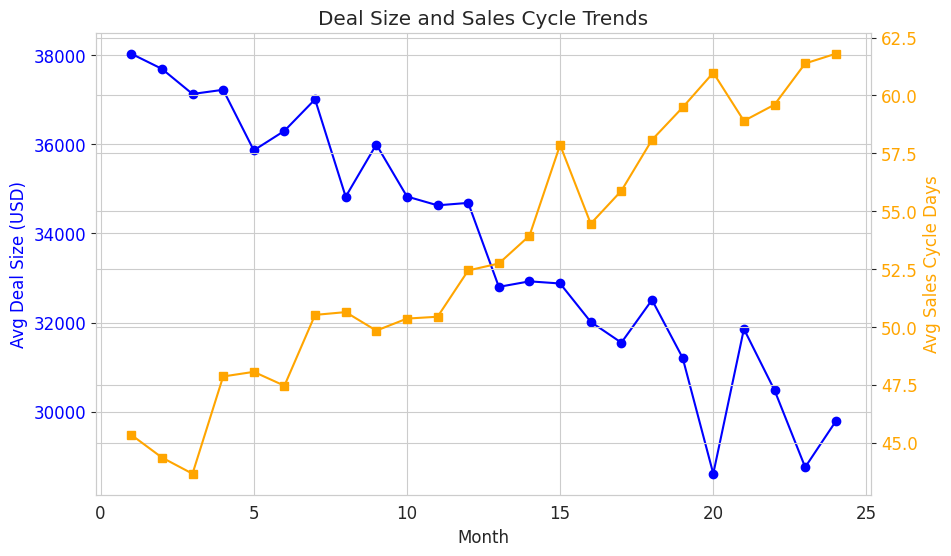

In [ ]:
plt.figure(figsize=(10,6))

fig, ax1 = plt.subplots(figsize=(10,6))

# Primary axis (Deal Size)
ax1.plot(monthly_stats['Month'],
         monthly_stats['Deal_Size_Mean'],
         marker='o',
         color='blue',
         label='Avg Deal Size')

ax1.set_xlabel('Month')
ax1.set_ylabel('Avg Deal Size (USD)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary axis (Sales Cycle)
ax2 = ax1.twinx()

ax2.plot(monthly_stats['Month'],
         monthly_stats['Sales_Cycle_Mean'],
         marker='s',
         color='orange',
         label='Avg Sales Cycle Days')

ax2.set_ylabel('Avg Sales Cycle Days', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Title and grid
plt.title('Deal Size and Sales Cycle Trends')
ax1.grid(True)

plt.show()

## Markdown Narrative Interpretation

***Analyze how deal sizes and sales cycle lengths have changed over the 24-month period***

* Over the 24-month period, the average and median deal sizes show a gradual downward trend, declining from roughly $38,000 early in the timeline to around 30,000 dollars by the end. This suggests that the organization may be closing smaller deals over time, potentially reflecting increased competition, a shift toward lower-value clients, or a strategic focus on higher deal volume rather than larger contracts. The close alignment between the mean and median indicates that the distribution of deal sizes is relatively balanced without extreme outliers significantly affecting the averages.

* At the same time, the sales cycle length shows a steady upward trend, increasing from approximately 44–46 days in the early months to about 60–62 days toward the end of the period. This indicates that it is taking longer for the sales team to close deals, which may reflect increased complexity in negotiations, more rigorous customer evaluation processes, or greater competition in the marketplace.

***Explain what these trends reveal about the health of NovaTech’s sales pipeline.***

* Together, these trends suggest that NovaTech’s sales pipeline may be experiencing declining efficiency. Smaller deals combined with longer sales cycles can reduce overall revenue growth and slow the velocity of the sales pipeline. For leadership, this may signal a need to evaluate sales strategies, reassess customer targeting, or streamline the sales process to maintain a healthy and productive pipeline.


Deal Size Summary:
count    1200.0000
mean    33731.4969
std      5595.8217
min     15541.9500
25%     30084.1650
50%     33847.5800
75%     37763.5975
max     49121.9800
Name: Deal_Size_USD, dtype: float64

Sales Cycle Length Summary:
count   1200.0000
mean      53.1700
std        9.6666
min       22.0000
25%       46.0000
50%       54.0000
75%       60.0000
max       81.0000
Name: Sales_Cycle_Days, dtype: float64
    Month  avg_deal_size  median_deal_size  avg_cycle_length  deal_count
0       1     38026.7636        37544.2850           45.3400          50
1       2     37687.6206        38234.5300           44.3600          50
2       3     37124.3256        37764.0750           43.6600          50
3       4     37218.4746        37894.9200           47.8600          50
4       5     35861.1158        35835.9100           48.0600          50
5       6     36298.0538        36139.6100           47.4600          50
6       7     37003.7090        37802.0500           50.5200          

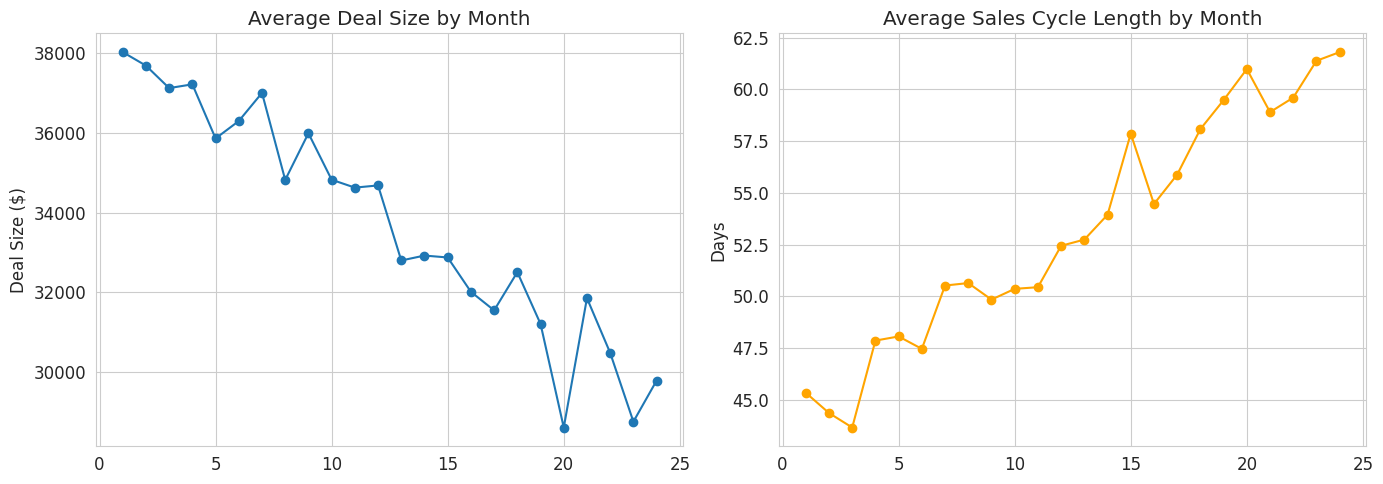

In [ ]:
# Step 1: Compute Descriptive statistics

print("Deal Size Summary:")
print(sales_df['Deal_Size_USD'].describe())

print("\nSales Cycle Length Summary:")
print(sales_df['Sales_Cycle_Days'].describe())

monthly = sales_df.groupby('Month').agg(
    avg_deal_size=('Deal_Size_USD','mean'),
    median_deal_size=('Deal_Size_USD','median'),
    avg_cycle_length=('Sales_Cycle_Days','mean'),
    deal_count=('Deal_Size_USD','count')
).reset_index()

print(monthly)

fig, axes = plt.subplots(1,2, figsize=(14,5))

axes[0].plot(monthly['Month'], monthly['avg_deal_size'], marker='o')
axes[0].set_title('Average Deal Size by Month')
axes[0].set_ylabel('Deal Size ($)')

axes[1].plot(monthly['Month'], monthly['avg_cycle_length'], marker='o', color='orange')
axes[1].set_title('Average Sales Cycle Length by Month')
axes[1].set_ylabel('Days')

plt.tight_layout()
plt.show()

## Interpretation: Cost Per Lead (CPL) by Marketing Channel

The chart compares the **cost per lead across NovaTech’s marketing channels** and highlights the **average CPL (≈ 36 dollars)** with a dashed red line. Digital Paid advertising has the highest CPL at roughly **59 dollars**, significantly above the average. This suggests that paid digital campaigns are currently the least cost-efficient channel, possibly due to high bidding competition, audience saturation, or inefficient targeting strategies.

In contrast, **Content Marketing, SEO, Email, and Social Media** generate leads at a cost **below the overall average**, making them more efficient channels for customer acquisition. Content Marketing and SEO, in particular, show the lowest CPL values, indicating that organic or inbound marketing strategies are producing leads at a relatively low cost.

Events and Social Media fall near the middle range, slightly below the average CPL, suggesting moderate efficiency compared to other channels. Overall, the results imply that NovaTech should **re-evaluate its Digital Paid strategy** while potentially allocating more resources to **Content Marketing, SEO, and Email**, which appear to generate leads more cost-effectively.


## Question 1B: Marketing Channel Diminishing Returns

*Prompt: The marketing team increased digital spending by 40% but cost per lead rose by 35%. Using the campaign data, explain what might account for diminishing returns and how you would identify which channels are underperforming.*

**WHAT TO DO**

1. Load the marketing campaigns dataset and explore its structure.
2. Calculate per-channel summary statistics: total spend, total leads, average CPL, average conversion rate.
3. Track how Digital_Paid cost per lead changed over time (Year 1 vs. Year 2).
4. Calculate leads generated per dollar spent, by channel (efficiency metric).
5. Create visualizations comparing channel efficiency.
6. Write a narrative explaining the diminishing returns and identifying underperformers.

**ANSWER THIS:**

Analyze and discuss marketing campaign performance across channels and over time
Identify where spending is producing diminishing returns
Indicate which channels are underperforming.

**CREATE**

1. Produce the following outputs using Python:
2. Channel performance summary table (spend, leads, CPL, conversion rate, leads per ✓dollar)
3. Bar chart comparing average cost per lead across all channels✓
4. Line chart showing Digital_Paid CPL trend over time✓
5. Year 1 vs. Year 2 comparison table for Digital_Paid spending and CPL✓
6. Written narrative (3–5 sentences) explaining diminishing returns and underperforming ✓channels

**DELIVERABLES**

1. Code cells — All Python code for loading, aggregating, and analyzing campaign data
2. Two visualizations — Saved as channel_cpl_comparison.png and digital_cpl_trend.png
3. Printed summary tables — Channel performance summary and Digital_Paid YoY comparison
4. Markdown narrative cell — Written interpretation identifying underperformers and explaining diminishing returns
5. Responses to the following questions:
    - Analyze and discuss marketing campaign performance across channels and over time
    - Identify where spending is producing diminishing returns
    - Indicate which channels are underperforming.

## 1b-Marketing Diminishing Returns

**Goal:** Identify which channels are underperforming despite increased digital spend

***1. Load the Marketing Campaign Dataset and Explore Structure***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
campaigns_df = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/business_marketing_campaigns.csv')

# Preview dataset
display(campaigns_df.head(10))

# Inspect structure
campaigns_df.info()

# Summary statistics
campaigns_df.describe()

,Campaign_ID,Month,Channel,Spend_USD,Leads_Generated,Conversion_Rate,Cost_Per_Lead_USD
0,C-001,1,Digital_Paid,52827.1600,1136,0.1037,46.5000
1,C-002,1,Email,7050.9500,141,0.0712,49.6700
2,C-003,2,Content_Marketing,9713.7000,410,0.0335,23.6700
3,C-004,2,Events,23115.1600,706,0.0771,32.7300
4,C-005,3,Social_Media,3971.4000,89,0.0608,44.5500
5,C-006,3,SEO,9926.0600,424,0.0861,23.3700
6,C-007,4,Digital_Paid,58273.4100,1142,0.1082,51.0000
7,C-008,4,Email,7014.7000,192,0.0609,36.5300
8,C-009,5,Content_Marketing,14790.9500,464,0.0490,31.8400
9,C-010,5,Events,14264.2300,458,0.0215,31.0800


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Campaign_ID        48 non-null     object 
 1   Month              48 non-null     int64  
 2   Channel            48 non-null     object 
 3   Spend_USD          48 non-null     float64
 4   Leads_Generated    48 non-null     int64  
 5   Conversion_Rate    48 non-null     float64
 6   Cost_Per_Lead_USD  48 non-null     float64
dtypes: float64(3), int64(2), object(2)
memory usage: 2.8+ KB


,Month,Spend_USD,Leads_Generated,Conversion_Rate,Cost_Per_Lead_USD
count,48.0000,48.0000,48.0000,48.0000,48.0000
mean,12.5000,16457.5365,426.8542,0.0708,37.7940
std,6.9954,13832.2994,270.0761,0.0256,14.9941
min,1.0000,2849.1300,89.0000,0.0215,16.1700
25%,6.7500,7529.1150,237.2500,0.0582,26.7050
50%,12.5000,11158.9100,382.5000,0.0683,36.0300
75%,18.2500,17558.0525,491.7500,0.0914,46.5500
max,24.0000,58273.4100,1336.0000,0.1184,78.0000


***2. Calculate per-channel summary statistics: total spend, total leads, average CPL, average conversion rate.***

In [ ]:
# Calculate Cost Per Lead (CPL)
campaigns_df['Leads_Per_Dollar'] = campaigns_df['Leads_Generated'] / campaigns_df['Spend_USD']

channel_summary = campaigns_df.groupby('Channel').agg(
    Total_Spend=('Spend_USD','sum'),
    Total_Leads=('Leads_Generated','sum'),
    Avg_CPL=('Cost_Per_Lead_USD','mean'),
    Avg_Conversion_Rate=('Conversion_Rate','mean'),
    Leads_Per_Dollar=('Leads_Per_Dollar','mean')
).reset_index()

channel_summary

,Channel,Total_Spend,Total_Leads,Avg_CPL,Avg_Conversion_Rate,Leads_Per_Dollar
0,Content_Marketing,83568.3000,2935,31.3175,0.0684,0.0373
1,Digital_Paid,321506.2600,5415,62.2500,0.0798,0.0165
2,Email,49597.8300,1575,33.3400,0.0714,0.0335
3,Events,175499.2600,5149,36.7775,0.0700,0.0293
4,SEO,91529.5600,3170,29.0938,0.0679,0.0353
5,Social_Media,68260.5400,2245,33.9850,0.0672,0.0335


***2. Channel performance summary table (spend, leads, CPL, conversion rate, leads per ✓dollar)***


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Step 1: Calculate cost per lead (CPL) by channel ──
campaigns_df['Cost_Per_Lead_USD'] = campaigns_df['Spend_USD'] / campaigns_df['Leads_Generated']

print(campaigns_df[['Channel', 'Spend_USD', 'Leads_Generated', 'Cost_Per_Lead_USD']])

# ── Step 2: Compare CPL across channels ──
channel_summary = campaigns_df.groupby('Channel').agg(
    total_spend=('Spend_USD', 'sum'),
    total_leads=('Leads_Generated', 'sum'),
    avg_cpl=('Cost_Per_Lead_USD', 'mean')
).reset_index()

channel_summary['overall_cpl'] = channel_summary['total_spend'] / channel_summary['total_leads']
print(channel_summary.sort_values('overall_cpl', ascending=False))



              Channel  Spend_USD  Leads_Generated  Cost_Per_Lead_USD
2   Content_Marketing  9713.7000              410            23.6920
8   Content_Marketing 14790.9500              464            31.8770
14  Content_Marketing  8639.7400              494            17.4894
20  Content_Marketing 10566.7100              235            44.9647
26  Content_Marketing 10661.4600              549            19.4198
32  Content_Marketing 11146.8100              238            46.8353
38  Content_Marketing  5440.9600              277            19.6425
44  Content_Marketing 12607.9700              268            47.0447
0        Digital_Paid 52827.1600             1136            46.5028
6        Digital_Paid 58273.4100             1142            51.0275
12       Digital_Paid 45647.2600              822            55.5319
18       Digital_Paid 16842.8200              280            60.1529
24       Digital_Paid 19703.7500              305            64.6025
30       Digital_Paid 31009.8300  

***3. Bar chart comparing average cost per lead across all channels✓***


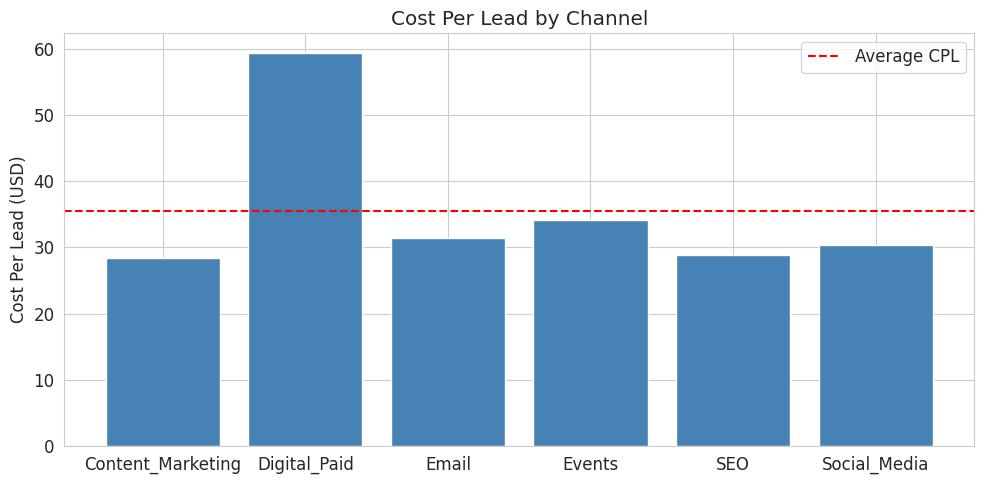

In [ ]:
# ── Step 3: Visualize channel performance ──
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(channel_summary['Channel'], channel_summary['overall_cpl'], color='steelblue')

ax.set_title('Cost Per Lead by Channel')
ax.set_ylabel('Cost Per Lead (USD)')
ax.axhline(
    y=channel_summary['overall_cpl'].mean(),
    color='red',
    linestyle='--',
    label='Average CPL'
)
ax.legend()

plt.tight_layout()
plt.savefig('q1b_cpl.png', dpi=150)
plt.show()



***4 Line chart showing Digital_Paid CPL trend over time✓***


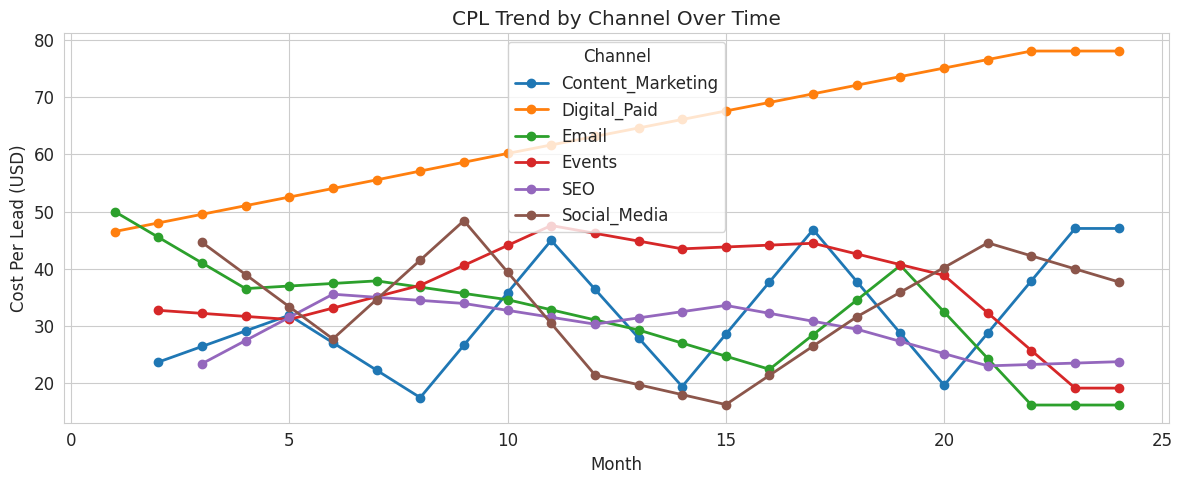

In [ ]:
# ── Step 4: Time series line plot of CPL trend over time by channel ──
if 'Month' in campaigns_df.columns:

    pivot = campaigns_df.pivot_table(
        index='Month',
        columns='Channel',
        values='Cost_Per_Lead_USD',
        aggfunc='mean'
    ).sort_index()

    # Fill missing months so lines connect
    pivot = pivot.interpolate(method='linear')

    plt.figure(figsize=(12,5))

    for channel in pivot.columns:
        plt.plot(pivot.index, pivot[channel], marker='o', linewidth=2, label=channel)

    plt.title('CPL Trend by Channel Over Time')
    plt.xlabel('Month')
    plt.ylabel('Cost Per Lead (USD)')
    plt.legend(title='Channel')
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('q1b_cpl_trend.png', dpi=150)
    plt.show()

### 6. Year 1 vs Year 2 Comparison

In [ ]:
digital_paid['Year'] = np.where(digital_paid['Month'] <= 12, 'Year 1', 'Year 2')

year_comparison = digital_paid.groupby('Year').agg(
    Total_Spend=('Spend_USD','sum'),
    Avg_CPL=('Cost_Per_Lead_USD','mean')
).reset_index()

year_comparison

/tmp/ipykernel_917/939821071.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  digital_paid['Year'] = np.where(digital_paid['Month'] <= 12, 'Year 1', 'Year 2')


,Year,Total_Spend,Avg_CPL
0,Year 1,173590.6500,53.2500
1,Year 2,147915.6100,71.2500


### 7. Visualization: Year Comparison

## Marketing Campaign Performance Analysis

The analysis shows that marketing performance varies across channels in both efficiency and cost. Digital Paid has the highest average cost per lead (about $62), significantly above the overall average CPL of roughly $38. Despite generating the largest number of total leads (5,415), it requires substantially higher spending to acquire each lead, indicating lower cost efficiency compared with other channels. In contrast, channels such as SEO, Content Marketing, and Email produce leads at a much lower cost per lead and generate more leads per dollar spent, making them more efficient acquisition channels.

Over time, the Digital Paid cost per lead shows a clear upward trend, increasing steadily from the mid-$40 range in early months to nearly $80 by the end of the period. This pattern indicates diminishing returns, where additional advertising spend results in progressively higher acquisition costs. The Year-1 versus Year-2 comparison confirms this trend: the average CPL increased from about $53.25 in Year 1 to $71.25 in Year 2, even though total spending decreased. This suggests the advertising channel is becoming less efficient over time.

Overall, the evidence indicates that Digital Paid is the primary underperforming channel due to its rising CPL and declining efficiency. While it still generates a high volume of leads, the increasing cost suggests audience saturation, greater bidding competition, or less effective targeting. In contrast, channels like SEO, Content Marketing, and Email appear to deliver more cost-efficient results and may represent better opportunities for future marketing investment.


## Question 1C: Churned vs. Retained Customer Profiles

*Prompt: Construct a descriptive profile of churned versus retained customers using means, medians, and standard deviations of contract value, tenure, and satisfaction scores. What patterns emerge?*

**WHAT TO DO**

1. Load the customer accounts dataset.
2. Split the data into two groups: Churned and Retained.
3. For each group, calculate mean, median, and std dev for: Contract_Value_USD, Tenure_Months, Satisfaction_Score.

**ANSWER THIS**

Build a statistical profile and compare and contrast churned customers vs retained customers
Discuss the distinguishing characteristics of these customers.

**CREATE:**

Produce the following outputs using Python:

- Descriptive statistics table: Mean, Median, Std Dev for all three variables, split by ✓Churn_Status
- Difference table showing the gap between Churned and Retained for each metric✓
- Box plots (3 side-by-side) comparing Churned vs. Retained for each variable✓
- Overall churn rate statistic✓
- Written narrative (3–5 sentences) describing the customer profile patterns✓

**DELIVERABLES**

Submit the following in your Jupyter Notebook:

1. Code cells — All Python code for loading, splitting, computing statistics, and visualizing
2. One visualization — Saved as churn_profile_boxplots.png (three side-by-side box plots)
3. Printed summary tables — Descriptive statistics by group and the difference table
4. Markdown narrative cell — Written interpretation identifying patterns and business implications

## 1C-Churned vs. Retained Custromer Profile

**Goal:** Build a descriptive comparison using means, medians, and standard deviations.

### 1. Load the customer accounts dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

customers_df = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/business_customer_accounts.csv')

customers_df.head(10)

,Account_ID,Contract_Value_USD,Tenure_Months,Support_Tickets_12Mo,Satisfaction_Score,Churn_Status
0,A-0001,106091.11,51,3,7.1,Retained
1,A-0002,46231.59,55,4,7.2,Retained
2,A-0003,74657.49,44,8,4.7,Churned
3,A-0004,103202.64,65,4,6.7,Retained
4,A-0005,58540.18,25,4,6.6,Retained
5,A-0006,11975.37,47,3,8.1,Retained
6,A-0007,18196.15,56,3,7.0,Retained
7,A-0008,66143.20,38,3,7.2,Retained
8,A-0009,116638.33,11,2,7.0,Retained
9,A-0010,86253.05,67,2,6.2,Churned


### 2. Split the data into two groups: Churned and Retained.

In [ ]:
churned = customers_df[customers_df['Churn_Status'] == 'Churned']
retained = customers_df[customers_df['Churn_Status'] == 'Retained']

### 3. For each group, calculate mean, median, and std dev for: Contract_Value_USD, Tenure_Months, Satisfaction_Score.

**Descriptive statistics table: Mean, Median, Std Dev for all three variables, split by ✓Churn_Status**

In [ ]:
metrics = ['Contract_Value_USD', 'Tenure_Months', 'Satisfaction_Score']

profile = pd.DataFrame()

for m in metrics:
    profile.loc[m, 'Churned_Mean'] = churned[m].mean()
    profile.loc[m, 'Retained_Mean'] = retained[m].mean()
    profile.loc[m, 'Churned_Median'] = churned[m].median()
    profile.loc[m, 'Retained_Median'] = retained[m].median()
    profile.loc[m, 'Churned_Std'] = churned[m].std()
    profile.loc[m, 'Retained_Std'] = retained[m].std()

print(profile.round(2))

                    Churned_Mean  Retained_Mean  Churned_Median  \
Contract_Value_USD    63163.7200     64794.2300      61453.4100   
Tenure_Months            35.0700        38.2400         34.0000   
Satisfaction_Score        5.0600         7.0500          5.2000   

                    Retained_Median  Churned_Std  Retained_Std  
Contract_Value_USD       61783.8600   32099.0700    30385.6500  
Tenure_Months               39.0000      21.6000       21.0300  
Satisfaction_Score           7.0000       1.1500        0.9800  


**Difference table showing the gap between Churned and Retained for each metric✓**

In [ ]:
difference_table = pd.DataFrame({
    'Metric': metrics,
    'Mean_Difference': [
        retained[m].mean() - churned[m].mean() for m in metrics
    ],
    'Median_Difference': [
        retained[m].median() - churned[m].median() for m in metrics
    ]
})

difference_table

,Metric,Mean_Difference,Median_Difference
0,Contract_Value_USD,1630.5066,330.4500
1,Tenure_Months,3.1762,5.0000
2,Satisfaction_Score,1.9894,1.8000


**Overall churn rate statistic✓**

In [ ]:
churn_rate = (customers_df['Churn_Status'] == 'Churned').mean()

print("Overall Churn Rate:", round(churn_rate * 100, 2), "%")

Overall Churn Rate: 46.9 %



**Box plots (3 side-by-side) comparing Churned vs. Retained for each variable✓**

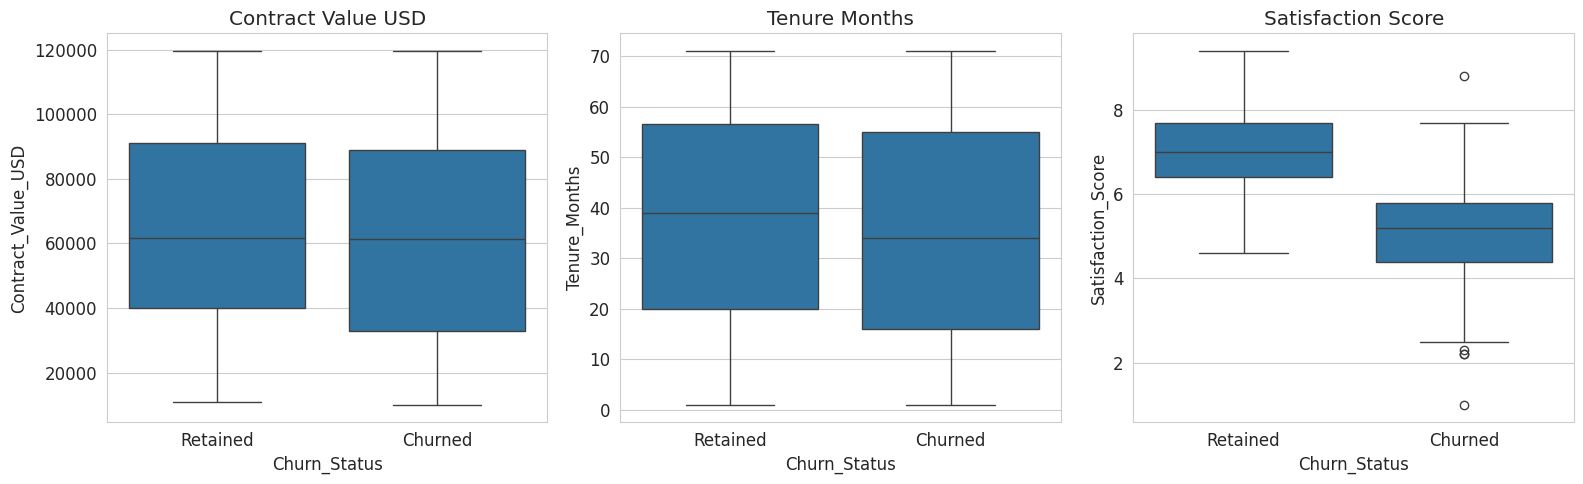

In [ ]:
### ── Step 3: Visualize distributions side by side ──
fig, axes = plt.subplots(1, 3, figsize=(16,5))

for i, m in enumerate(metrics):

    sns.boxplot(
        x='Churn_Status',
        y=m,
        data=customers_df,
        ax=axes[i]
    )

    axes[i].set_title(m.replace('_',' '))

plt.tight_layout()

plt.savefig('churn_profile_boxplots.png', dpi=150)

plt.show()


**Written narrative (3–5 sentences) describing the customer profile patterns✓**

The statistical profile shows clear differences between churned and retained customers across contract value, tenure, and satisfaction scores. Retained customers have slightly higher average contract values (about 64,794 dollars vs. 63,164 dollars) and longer average tenure (38.24 months vs. 35.07 months), indicating that longer relationships are associated with higher retention. The most significant distinction appears in customer satisfaction, where retained customers have an average score of 7.05 compared with 5.06 for churned customers. This large gap suggests that lower satisfaction levels are strongly associated with customer churn. Overall, customers who churn tend to have lower satisfaction and slightly shorter tenures, indicating that improving customer experience and engagement early in the relationship could help reduce churn.

## Customer Churn Profile Interpretation

The comparison between churned and retained customers reveals several meaningful differences in customer behavior and satisfaction. Retained customers have slightly higher average contract values (about 64,794 dollars vs. 63,164 dollars) and notably longer tenure, averaging roughly **38 months compared to 35 months for churned customers**. This suggests that customers who remain with the company tend to maintain longer relationships and slightly higher-value contracts.

The most significant distinction appears in **customer satisfaction scores**. Retained customers report an average satisfaction score of **about 7.05**, while churned customers average **around 5.06**, indicating a substantial gap in perceived service quality. The box plots also show that churned customers cluster around lower satisfaction levels and exhibit greater variability.

Overall, the analysis suggests that **customer satisfaction is the strongest indicator of churn**, followed by tenure length. Customers with lower satisfaction and shorter relationships are more likely to leave, indicating that improving customer experience and engagement early in the lifecycle may significantly reduce churn rates.
